In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Day 2 - Data Exploration

Loading the CAlifornia Housing dataset and getting a first look at it.

Goal : Understand what features the dataset has, how many rows, and whether there are any data quality issues.

In [107]:
from sklearn.datasets import fetch_california_housing

data = fetch_california_housing()

In [108]:
df = pd.DataFrame(data.data, columns=data.feature_names)
df['Price'] = data.target

In [109]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [110]:
df.shape

(20640, 9)

In [111]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [112]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [113]:
df.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64

## Day 2 - What I Learned

1)how to import california housing dataset

2)And arranged raw data into table form for easy to readable

# About DataSet
* 20,640 rows, 9 columns
* all columns are numeric(float64)
* And No errors in dataset

# Features
* MedInc - median income
* HouseAge - average house age
* AveRooms, AveBedrms - average rooms and bedrooms
* Population, AveOccup - population data
* Latitude, Logitude- location

# Things I noticed:
* Max value is 5.0
* Income(MedInc) varies a lot - 0.5 - 5.0

Day 3 - Data Visualizing

Make plots to see patterns in data . numbers tells you facts:
plots tell you stories


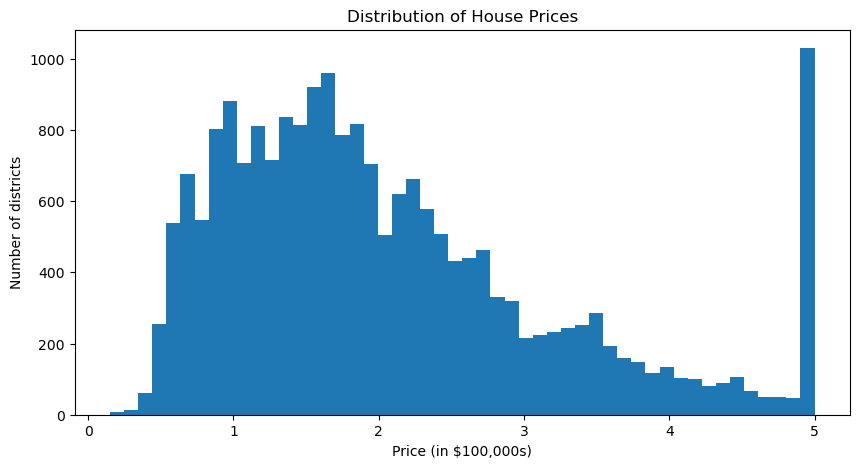

In [114]:


plt.figure(figsize=(10, 5))
plt.hist(df['Price'], bins=50)
plt.xlabel('Price (in $100,000s)')
plt.ylabel('Number of districts')
plt.title('Distribution of House Prices')
plt.show()

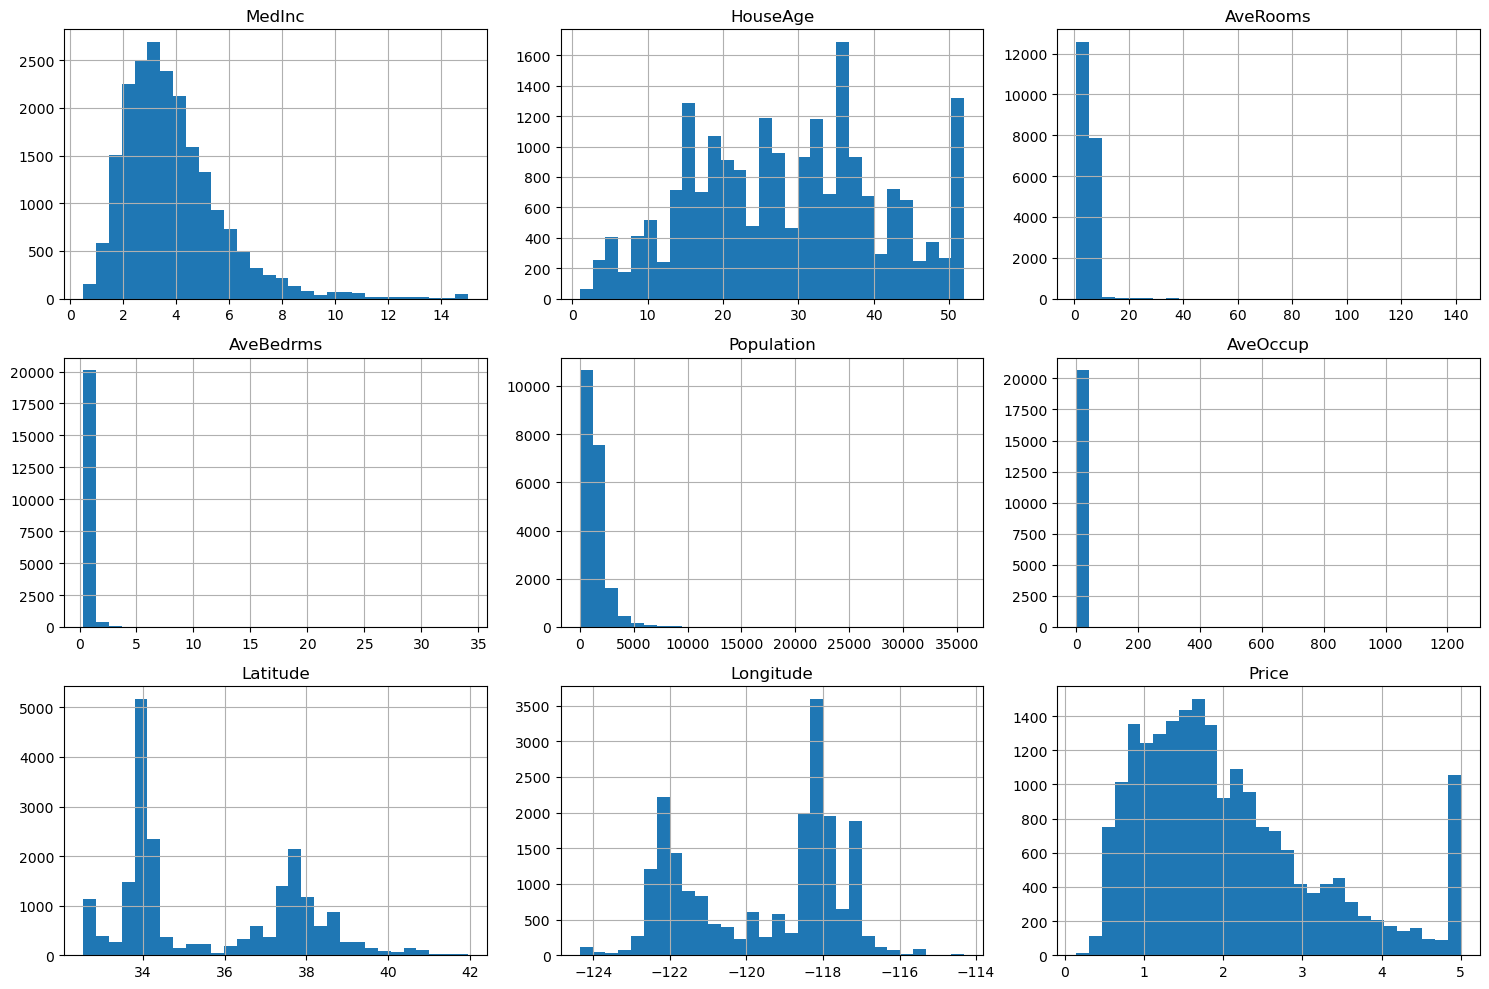

In [115]:
df.hist(figsize=(15, 10), bins=30)
plt.tight_layout()
plt.show()

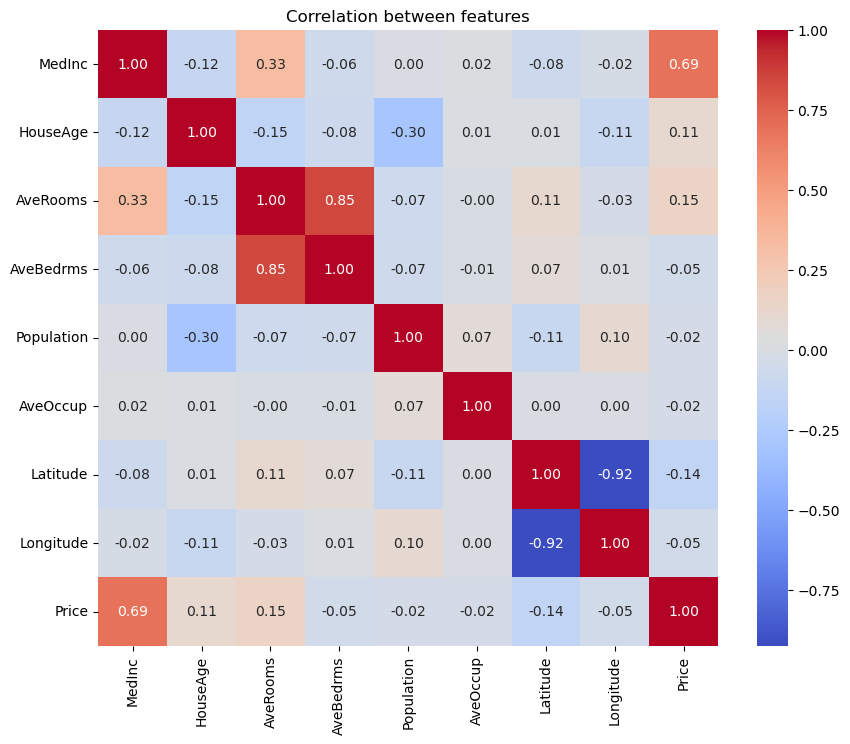

In [116]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation between features')
plt.show()

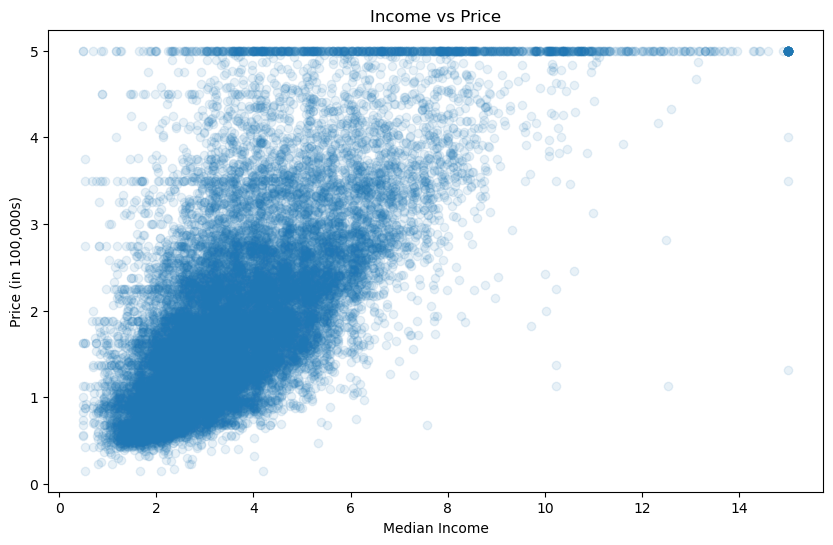

In [117]:
plt.figure(figsize=(10, 6))
plt.scatter(df['MedInc'], df['Price'], alpha=0.1)
plt.xlabel('Median Income')
plt.ylabel("Price (in 100,000s)")
plt.title('Income vs Price')
plt.show()

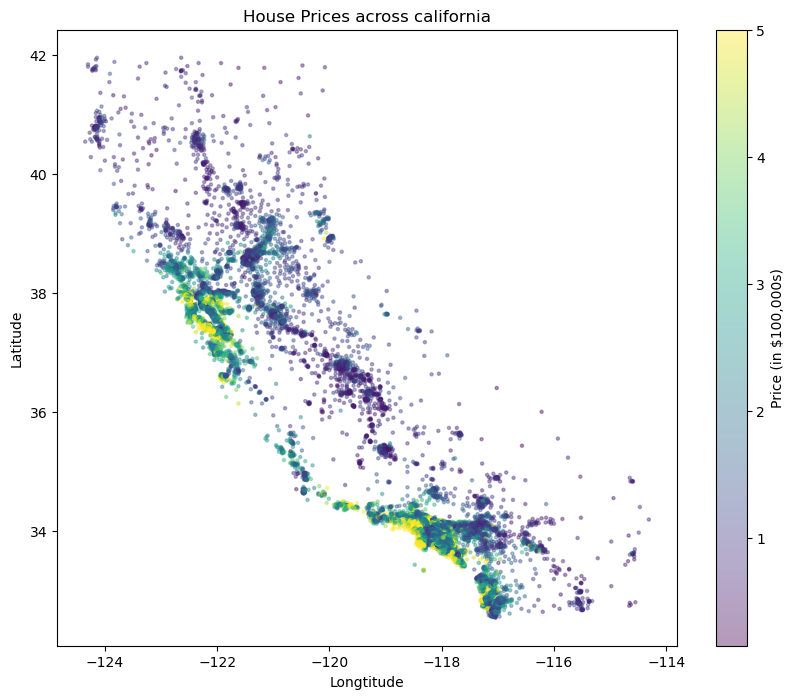

In [118]:
from scipy.__config__ import show
plt.figure(figsize=(10, 8))
plt.scatter(df['Longitude'], df['Latitude'],
            c=df['Price'], cmap='viridis', alpha=0.4, s=5)
plt.colorbar(label='Price (in $100,000s)')
plt.xlabel('Longtitude')
plt.ylabel('Latitude')
plt.title('House Prices across california')
plt.show()

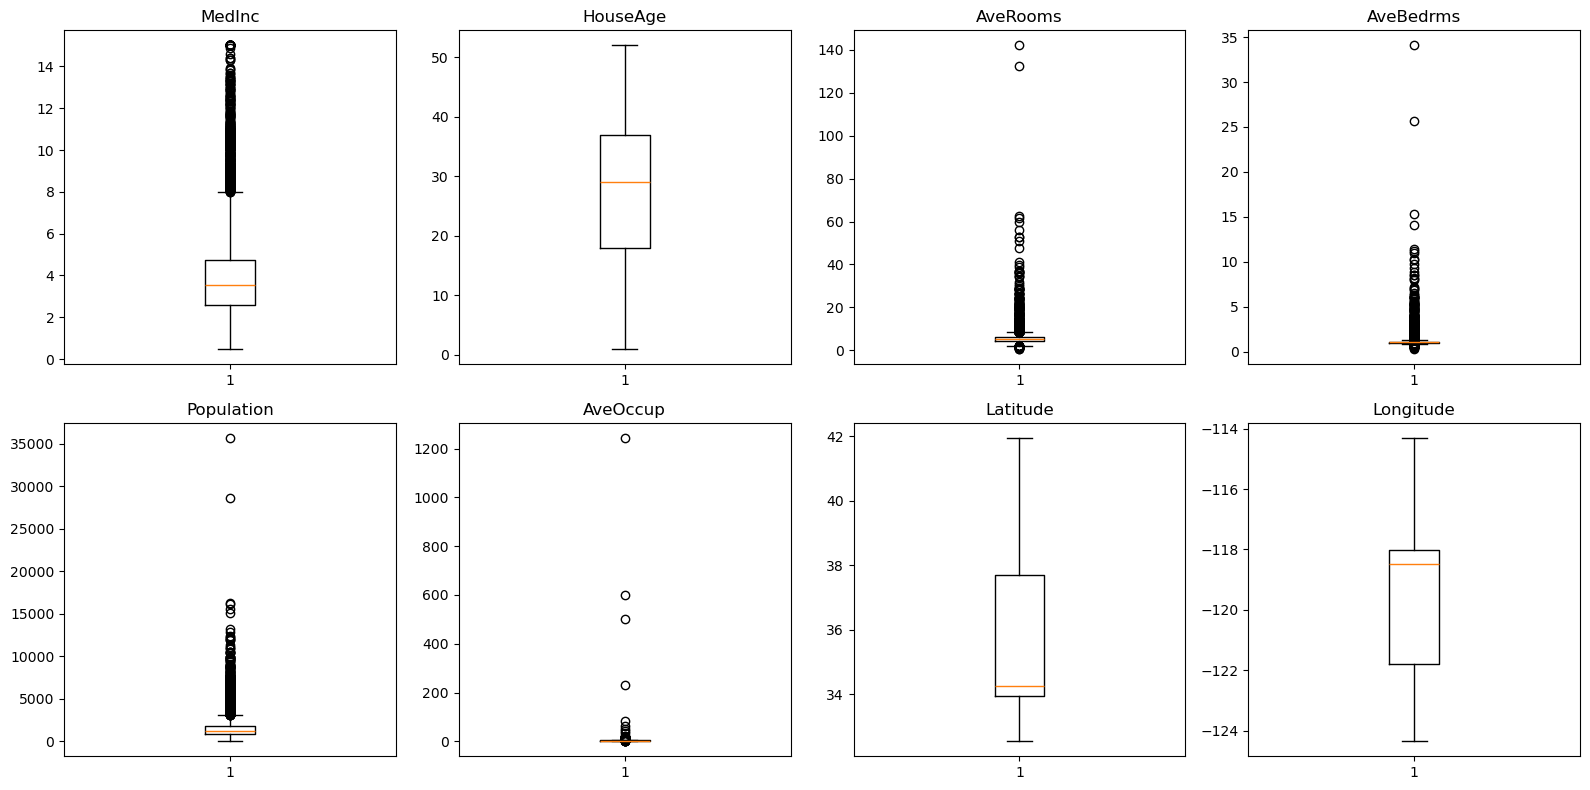

In [119]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
features = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

for i, feature in enumerate(features):
  row = i // 4
  col = i % 4
  axes[row, col].boxplot(df[feature])
  axes[row, col].set_title(feature)

plt.tight_layout()
plt.show()


## Day 3 what i have learneed from the plots

About Price:
  1. Most of the districts have price between 100k to 300k.
  2. Big spike at 500k mean too expensive but they mislabled data.
  3. My model will struggle with expensive houses

About Relationship with data (From heatmap):
  1. MedInc has the highest corrletion with price(~0.69).
  2. so Income matters more than I thought

About Geography
  1. by the Way I get to know coast are expensive
  2. inland areaas are cheaper
  3. loaction matters

About Data quality
  1. AVerooms, AveBedrooms, AveOccp have major outliers
  2. will handle later

Feature to matter:
  1. MedInc - confirmed by correlation
  2. Latitude / Longitude - Confirmed by California map





# Day 4: Data Analysis & Decisions

Investigate Data Quality in Day 3 and deciding how to handle them before modeling


In [120]:
# Step 1: Top 3 features most correlated with Price
correlations = df.corr()['Price'].drop('Price').sort_values(ascending=False)
print("All feature correlations with Price:\n")
print(correlations)
print("\n--- Top 3 ---")
print(correlations.head(3))

All feature correlations with Price:

MedInc        0.688075
AveRooms      0.151948
HouseAge      0.105623
AveOccup     -0.023737
Population   -0.024650
Longitude    -0.045967
AveBedrms    -0.046701
Latitude     -0.144160
Name: Price, dtype: float64

--- Top 3 ---
MedInc      0.688075
AveRooms    0.151948
HouseAge    0.105623
Name: Price, dtype: float64


Total rows with Price >= $500K: 994
That's 4.8% of the dataset



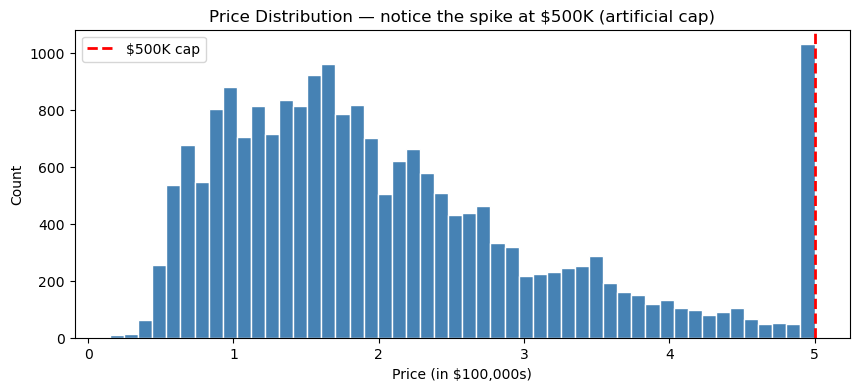

In [121]:
# Step 2: Investigate the $500K price cap
# Price is in $100,000s, so 5.0 = $500,000
capped_rows = df[df['Price'] >= 4.99]
print(f"Total rows with Price >= $500K: {len(capped_rows)}")
print(f"That's {len(capped_rows)/len(df)*100:.1f}% of the dataset")
print()

# Visualize the cap
plt.figure(figsize=(10, 4))
plt.hist(df['Price'], bins=50, color='steelblue', edgecolor='white')
plt.axvline(x=5.0, color='red', linestyle='--', linewidth=2, label='$500K cap')
plt.xlabel('Price (in $100,000s)')
plt.ylabel('Count')
plt.title('Price Distribution — notice the spike at $500K (artificial cap)')
plt.legend()
plt.show()

In [122]:
# Step 3: Investigate outliers in AveRooms and AveOccup
print("=== AveRooms stats ===")
print(df['AveRooms'].describe())
print(f"\nRows with AveRooms > 50: {len(df[df['AveRooms'] > 50])}")

print("\n=== AveOccup stats ===")
print(df['AveOccup'].describe())
print(f"\nRows with AveOccup > 20: {len(df[df['AveOccup'] > 20])}")

# Show the extreme outliers
print("\n=== Worst AveRooms outliers ===")
print(df.nlargest(5, 'AveRooms')[['AveRooms', 'AveOccup', 'Population', 'Price']])

=== AveRooms stats ===
count    20640.000000
mean         5.429000
std          2.474173
min          0.846154
25%          4.440716
50%          5.229129
75%          6.052381
max        141.909091
Name: AveRooms, dtype: float64

Rows with AveRooms > 50: 9

=== AveOccup stats ===
count    20640.000000
mean         3.070655
std         10.386050
min          0.692308
25%          2.429741
50%          2.818116
75%          3.282261
max       1243.333333
Name: AveOccup, dtype: float64

Rows with AveOccup > 20: 10

=== Worst AveRooms outliers ===
         AveRooms  AveOccup  Population    Price
1914   141.909091  2.727273        30.0  5.00001
1979   132.533333  2.400000        36.0  1.62500
12447   62.422222  1.844444        83.0  0.87500
1913    61.812500  2.333333       112.0  4.37500
11862   59.875000  1.750000        28.0  0.67500


## Data Findings

### Top 3 Features Correlated with Price
1. **MedInc (~0.69)** — Strongest signal by far. Wealthier districts = higher prices.
2. **AveRooms (~0.15)** — More rooms generally means a more expensive home.
3. **HouseAge (~0.11)** — Older homes in California tend to be in established (expensive) areas.

Note: Latitude has a negative correlation (-0.14) — southern CA tends to be more expensive than northern inland areas.

### Data Quality Issues

**Problem 1: Price cap near $500K**
- We used threshold >= 4.99 ($499K) to catch all capped/near-capped rows.
- These rows have artificially limited prices due to data collection limits.
- **Impact:** Our model will underpredict for expensive homes. We'll decide in Phase 3 whether to drop these rows or keep them.

**Problem 2: Outliers in AveRooms and AveOccup**
- Most districts have 4–8 average rooms, but 9 rows spike above 50 — likely hotels or dorms.
- AveOccup goes up to 1243 people per household — clearly bad data for tiny census blocks (10 rows above 20).
- **Impact:** These outliers will skew linear models. We'll remove them in Phase 3.

### Features Expected to Matter Most
| Feature | Why |
|---|---|
| MedInc | Strongest correlation (0.69) |
| Latitude + Longitude | Location drives California prices heavily |
| AveRooms | Larger homes cost more |
| HouseAge | Older established areas tend to be pricier |

### What I Noticed
- California housing is heavily driven by **where** and **how rich** — income and location carry most of the signal.
- The price cap near $500K is the biggest data quality issue and will hurt predictions on expensive homes.
- AveRooms/AveOccup outliers are very few rows but extreme — they need to be handled before modeling.